# CLUSTERING ANALYSIS 

**Understanding and Implementing K-Means and DBSCAN Algorithms**    

Objective:
The objective of this assignment is to introduce to various clustering algorithms, including K-Means, hierarchical, and DBSCAN, and provide hands-on experience in applying these techniques to a real-world dataset.   

**Datasets :**  
## 1.Data Preprocessing: 

**1.Preprocess the dataset to handle missing values, remove outliers, and scale the features if necessary.**

In [1]:
# Load the Dataset 
import pandas as pd 

df = pd.read_excel("EastWestAirlines.xlsx", sheet_name="data")

In [2]:
# Check Missing Values 
df.isnull().sum()

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

In [3]:
# Check Duplicate 
df.duplicated().sum()

np.int64(0)

In [4]:
# Check Outlier
# import matplotlib.pyplot as plt 
# import seaborn as sns 

# for col in df.select_dtypes(include = ['int','float']).columns:
#     sns.boxplot(df[col])
#     plt.show()

In [5]:
# Outlier Capping 
for i in df.select_dtypes(include = ['int','float']).columns:
    q1 = df[i].quantile(0.25)
    q3 = df[i].quantile(0.75)

    IQR  = q1 - q3 
    lower_bound = q1 - 1.5*IQR
    upper_bound = q3 + 1.5*IQR

    df[i] = df[i].clip(lower_bound, upper_bound)

In [6]:
# Verify
# import matplotlib.pyplot as plt 
# import seaborn as sns 

# for col in df.select_dtypes(include = ['int','float']).columns:
#     sns.boxplot(df[col])
#     plt.show()

**2.	Perform exploratory data analysis (EDA) to gain insights into the distribution of data and identify potential clusters.**

In [7]:
# Head of the Dataset 
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,5.5,28143.0,0,1,1,1,174.00,1,0.0,0.0,7000.0,0
1,5.5,19244.0,0,1,1,1,215.00,2,0.0,0.0,6968.0,0
2,5.5,41354.0,0,1,1,1,4123.00,4,0.0,0.0,7034.0,0
3,5.5,14776.0,0,1,1,1,500.00,1,0.0,0.0,6952.0,0
4,5.5,97752.0,0,4,1,1,35075.75,24,466.5,1.5,6935.0,1


In [8]:
# Tail of the Dataset 
df.tail()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
3994,4017.0,18476.0,0,1,1,1,8525.0,4,200.0,1.0,1403.0,1
3995,4018.0,64385.0,0,1,1,1,981.0,5,0.0,0.0,1395.0,1
3996,4019.0,73597.0,0,3,1,1,25447.0,8,0.0,0.0,1402.0,1
3997,4020.0,54899.0,0,1,1,1,500.0,1,466.5,1.0,1401.0,0
3998,4021.0,3016.0,0,1,1,1,0.0,0,0.0,0.0,1398.0,0


In [9]:
# Shape of Dataset 
df.shape

(3999, 12)

In [10]:
# Columns of Dataset
df.columns

Index(['ID#', 'Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles',
       'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12',
       'Days_since_enroll', 'Award?'],
      dtype='object')

In [11]:
# General Information 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID#                3999 non-null   float64
 1   Balance            3999 non-null   float64
 2   Qual_miles         3999 non-null   int64  
 3   cc1_miles          3999 non-null   int64  
 4   cc2_miles          3999 non-null   int64  
 5   cc3_miles          3999 non-null   int64  
 6   Bonus_miles        3999 non-null   float64
 7   Bonus_trans        3999 non-null   int64  
 8   Flight_miles_12mo  3999 non-null   float64
 9   Flight_trans_12    3999 non-null   float64
 10  Days_since_enroll  3999 non-null   float64
 11  Award?             3999 non-null   int64  
dtypes: float64(6), int64(6)
memory usage: 375.0 KB


In [12]:
# Statistical Summary 
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID#,3999.0,2014.822581,1160.758942,5.50,1010.5,2016.0,3020.5,4021.00
Balance,3999.0,56203.310328,43699.336481,0.00,18527.5,43097.0,92404.0,129342.25
Qual_miles,3999.0,0.000000,0.000000,0.00,0.0,0.0,0.0,0.00
cc1_miles,3999.0,1.987497,1.240610,1.00,1.0,1.0,3.0,4.00
cc2_miles,3999.0,1.000000,0.000000,1.00,1.0,1.0,1.0,1.00
cc3_miles,3999.0,1.000000,0.000000,1.00,1.0,1.0,1.0,1.00
Bonus_miles,3999.0,12898.245936,13151.791644,0.00,1250.0,7171.0,23800.5,35075.75
Bonus_trans,3999.0,10.851463,7.800536,0.00,3.0,12.0,17.0,24.00
Flight_miles_12mo,3999.0,126.161540,197.807886,0.00,0.0,0.0,311.0,466.50
Flight_trans_12,3999.0,0.419980,0.628527,0.00,0.0,0.0,1.0,1.50


**3.	Use multiple visualizations to understand the hidden patterns in the dataset.**

In [13]:
# HIST PLOT 
import matplotlib.pyplot as plt 
import seaborn as sns

# for col in df.columns:
#     sns.histplot(df[col])
#     plt.xlabel(col)
#     plt.ylabel("Frequency")
#     plt.title(col)
#     plt.tight_layout()
#     plt.show()
    

In [14]:
# KDE PLOT 
import matplotlib.pyplot as plt 
import seaborn as sns 

# for col in df.columns:
#     sns.kdeplot(df[col], fill = True)
#     plt.xlabel(col)
#     plt.ylabel("Frequency")
#     plt.title(col)
#     plt.tight_layout()
#     plt.show()

## 2. Implementing Clustering Algorithms:  

**1.•	Implement the K-Means and DBSCAN algorithms using a programming language such as Python with libraries like scikit-learn.**

In [15]:
# Drop Unwanted columns:
df.drop(columns = 'ID#', inplace = True)

In [16]:
# Standardization 
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()

df[['Bonus_miles','Days_since_enroll']] = scaler.fit_transform(df[['Bonus_miles','Days_since_enroll']])


In [28]:
# Implementation of KMEANS 
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters = 2,
               random_state=42,
                n_init=10)


In [29]:
# Implementation of DBSCAN
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

**2. Apply each clustering algorithm to the pre-processed dataset to identify clusters within the data.**  

In [30]:
# Apply KMeans 

# Model Training 
kmeans_clusters = kmeans.fit(df)
kmeans_clusters.labels_

array([0, 0, 0, ..., 1, 0, 0], shape=(3999,), dtype=int32)

In [31]:
# Check Clusters
import numpy as np 

np.unique (kmeans_clusters.labels_)

array([0, 1], dtype=int32)

In [32]:
# Apply DBSCAN

# Model Training 
dbscan_clusters = dbscan.fit(df)

dbscan_clusters.labels_

array([-1, -1, -1, ..., -1, -1, -1], shape=(3999,))

In [33]:
# Check Clusters

import numpy as np 
np.unique(dbscan_clusters.labels_)

array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8])

**3.Experiment with different parameter settings for K-means (Elbow curve for different K values) and DBSCAN (e.g., epsilon, minPts) and evaluate the clustering results.**   

In [34]:
# Experiment with diffrent parameter for KMeans 

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

kmeans = KMeans(n_clusters= 2 ,
                init = "k-means++",  # random
                n_init= 10,
                max_iter=300,
                random_state = 42)
clusters = kmeans.fit(df)
clusters.labels_

# Evaluation
# Silhouette Score 
silhouette = silhouette_score(df, clusters.labels_)

# Davies_bouldin_score
db_score = davies_bouldin_score(
    df,
    clusters.labels_
)


# Inertia
inertia = kmeans.inertia_

print("K-Means Evaluation")
print("-------------------")
print("Silhouette Score:", silhouette)
print("Davies-Bouldin Index:", db_score)
print("Inertia / WCSS:", round(inertia, 4))

K-Means Evaluation
-------------------
Silhouette Score: 0.6968539439044417
Davies-Bouldin Index: 0.4245410957887199
Inertia / WCSS: 1539276093029.2815


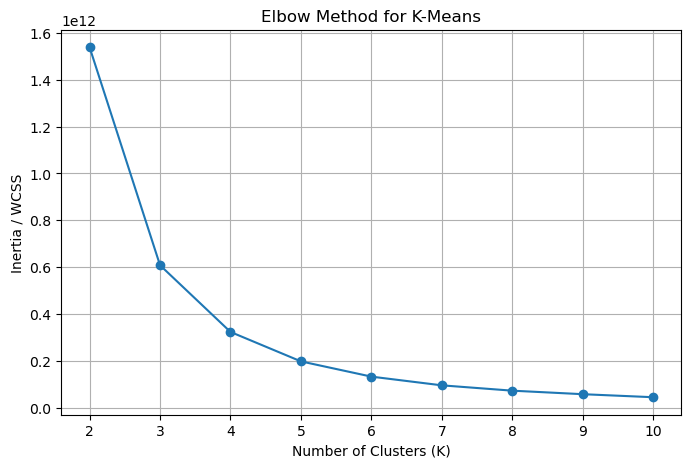

In [35]:
# Elbow method 
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(df)

    inertia.append(kmeans.inertia_)

# Plot 
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia / WCSS")
plt.title("Elbow Method for K-Means")

plt.grid()
plt.show()

In [36]:
# Experiment wiht diffrent parameter DBSCAN 
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score


dbscan = DBSCAN(eps= 0.7, 
                min_samples= 5, 
                 metric="euclidean"
                )

dbscan.clusters = dbscan.fit(df)

# Evaluation 
# Silhouette Score 
dbscan_silhouette = silhouette_score(df, dbscan.clusters.labels_)

# Davies_bouldin_score
dbscan_db_score = davies_bouldin_score(
    df,
    dbscan.clusters.labels_
)

print("DBSCAN Evaluation")
print("-------------------")
print("Silhouette Score:", dbscan_silhouette)
print("Davies-Bouldin Index:", dbscan_db_score)


DBSCAN Evaluation
-------------------
Silhouette Score: -0.34793097699630865
Davies-Bouldin Index: 0.7669648960994283


## 3.Cluster Analysis and Interpretation:  
•	Analyse the clusters generated by each clustering algorithm and interpret the characteristics of each cluster.   
Write you insights in few comments.

In [37]:
# Comparison
comparison = pd.DataFrame({
    "Model" : ['KMeans','DBSCAN'],
    "Silhouette Score" : [silhouette,dbscan_silhouette],
    "Davies-Bouldin Index" : [db_score, dbscan_db_score]
})
comparison

,Model,Silhouette Score,Davies-Bouldin Index
0,KMeans,0.696854,0.424541
1,DBSCAN,-0.347931,0.766965


## 4. Visualization:  
Visualize the clustering results using scatter plots or other suitable visualization techniques.  
Plot the clusters with different colours to visualize the separation of data points belonging to different clusters.  
Evaluation and Performance Metrics:  
Evaluate the quality of clustering using internal evaluation metrics such as silhouette score for K-Means and DBSCAN.

TypeError: float() argument must be a string or a real number, not 'KMeans'

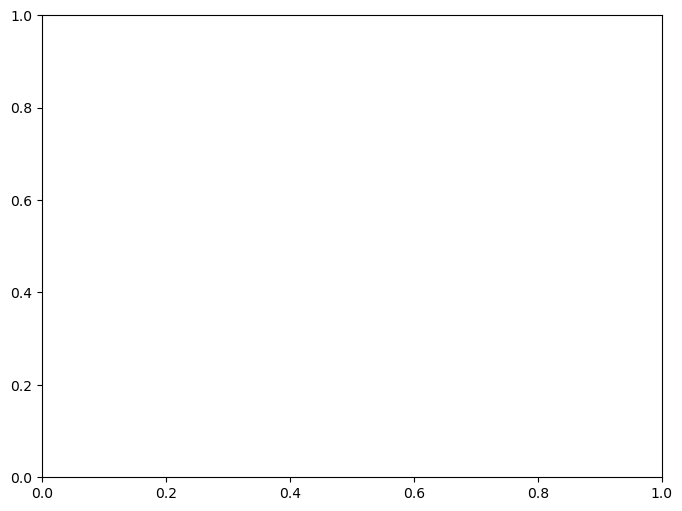

In [38]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce standardized wine data to 2 dimensions
pca = PCA(n_components=2)

x_pca = pca.fit_transform(df)

# Scatter plot
plt.figure(figsize=(8, 6))

plt.scatter(
    x_pca[:, 0],
    x_pca[:, 1],
    c=clusters,
    cmap="viridis",
    s=50
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering on Wine Dataset")

plt.colorbar(label="Cluster")

plt.show()